# Linear Regression — Gradient Descent with Convergence

In this notebook, we implement **linear regression from scratch** using gradient descent.

Instead of deciding beforehand that gradient descent must run for a fixed number such as 2,000 iterations, we let the algorithm continue until the parameters have effectively stopped changing.

The flow is:

1. Define the model
2. Define the cost function
3. Compute the gradients
4. Update $w$ and $b$
5. Check whether $w$ and $b$ have converged
6. Record the iteration history
7. Evaluate the final model


## Dataset

We use a small dataset containing house size and price.

The points are intentionally **not perfectly linear**, so the model has a meaningful error to minimize.

| House | Size $x$ | Price $y$ |
|---:|---:|---:|
| 1 | 1 | 3 |
| 2 | 2 | 5 |
| 3 | 3 | 7 |
| 4 | 4 | 8 |
| 5 | 5 | 11 |
| 6 | 6 | 12 |
| 7 | 7 | 14 |
| 8 | 8 | 17 |

Here:

- $x$ = input feature
- $y$ = target value
- $m$ = number of training examples


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([1., 2., 3., 4., 5., 6., 7., 8.])
y_train = np.array([3., 5., 7., 8., 11., 12., 14., 17.])

m = x_train.shape[0]

print("Number of training examples:", m)


Number of training examples: 8


## 1. Model

For one feature, linear regression uses:

$$
f_{w,b}(x)=wx+b
$$

Where:

- $w$ = parameter controlling the slope
- $b$ = parameter controlling the intercept
- $x$ = input
- $f_{w,b}(x)$ = predicted value

The objective is to find the values of $w$ and $b$ that give predictions as close as possible to the actual $y$ values.


In [2]:
def compute_prediction(x, w, b):
    return w * x + b


w = 0.0
b = 0.0

print("Initial w:", w)
print("Initial b:", b)


Initial w: 0.0
Initial b: 0.0


## 2. Cost Function

For each training example:

$$
error^{(i)}=f_{w,b}(x^{(i)})-y^{(i)}
$$

The cost function is:

$$
J(w,b)=
\frac{1}{2m}
\sum_{i=0}^{m-1}
\left(f_{w,b}(x^{(i)})-y^{(i)}\right)^2
$$

The objective is:

$$
\boxed{\min_{w,b}J(w,b)}
$$

A smaller value of $J(w,b)$ means the predictions are, overall, closer to the actual values.


In [3]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    predictions = compute_prediction(x, w, b)
    errors = predictions - y

    return np.sum(errors ** 2) / (2 * m)


print("Initial cost:", compute_cost(x_train, y_train, w, b))


Initial cost: 56.0625


## 3. Gradient Descent

The gradients are:

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}
\sum_{i=0}^{m-1}
\left(f_{w,b}(x^{(i)})-y^{(i)}\right)x^{(i)}
$$

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=0}^{m-1}
\left(f_{w,b}(x^{(i)})-y^{(i)}\right)
$$

The update equations are:

$$
w_{new}=w-\alpha\frac{\partial J}{\partial w}
$$

$$
b_{new}=b-\alpha\frac{\partial J}{\partial b}
$$

Where $\alpha$ is the learning rate.


In [4]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]

    predictions = compute_prediction(x, w, b)
    errors = predictions - y

    dj_dw = np.sum(errors * x) / m
    dj_db = np.sum(errors) / m

    return dj_dw, dj_db


## 4. When Should Gradient Descent Stop?

There is no mathematical requirement that we run exactly 2,000 iterations.

After an update, we get new values:

$$
w_{new}, b_{new}
$$

We compare them with the previous values:

$$
|w_{new}-w|
$$

and

$$
|b_{new}-b|
$$

If both changes become extremely small, another iteration will make practically no difference.

Therefore, we can define a small tolerance $\epsilon$:

$$
|w_{new}-w|<\epsilon
$$

and

$$
|b_{new}-b|<\epsilon
$$

When both conditions are satisfied, we consider the model to have **converged**.

> In exact mathematical arithmetic, the parameters may approach the minimum without becoming literally identical. In computer calculations, we therefore use a small tolerance rather than waiting for exact equality.


## 5. Gradient Descent with Convergence

At every iteration we will record:

- iteration number
- old $w$
- new $w$
- change in $w$
- old $b$
- new $b$
- change in $b$
- cost

This gives us a history of how the parameters move toward convergence.

A maximum iteration limit is still kept as a **safety limit**, not as the stopping condition we normally expect to reach.


In [5]:
def gradient_descent_until_convergence(
    x,
    y,
    w_init=0.0,
    b_init=0.0,
    alpha=0.01,
    tolerance=1e-10,
    max_iters=100000
):
    w = w_init
    b = b_init

    history = []

    for iteration in range(1, max_iters + 1):
        # Calculate gradients using current w and b
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        # Calculate new parameters
        new_w = w - alpha * dj_dw
        new_b = b - alpha * dj_db

        # Parameter changes
        change_w = abs(new_w - w)
        change_b = abs(new_b - b)

        # Cost after the update
        cost = compute_cost(x, y, new_w, new_b)

        history.append({
            "iteration": iteration,
            "w": new_w,
            "b": new_b,
            "change_w": change_w,
            "change_b": change_b,
            "cost": cost
        })

        # Display selected iterations as a running log
        if iteration <= 10 or iteration % 1000 == 0:
            print(
                f"Iteration {iteration:5d} | "
                f"w = {new_w:.10f} | "
                f"b = {new_b:.10f} | "
                f"Δw = {change_w:.3e} | "
                f"Δb = {change_b:.3e} | "
                f"Cost = {cost:.10f}"
            )

        # Move to the new parameters
        w = new_w
        b = new_b

        # Stop when another update would be negligibly small
        if change_w < tolerance and change_b < tolerance:
            print("\nConvergence reached.")
            break

    else:
        print("\nMaximum iteration limit reached.")

    return w, b, history


## 6. Run Gradient Descent

We start with:

$$
w=0,\qquad b=0
$$

and repeatedly update them.

The algorithm stops when:

$$
|\Delta w|<\epsilon
$$

and

$$
|\Delta b|<\epsilon
$$

In this implementation:

$$
\epsilon=10^{-10}
$$

The value is a numerical tolerance used to decide that further changes are negligible.


In [6]:
w, b, history = gradient_descent_until_convergence(
    x_train,
    y_train,
    w_init=0.0,
    b_init=0.0,
    alpha=0.01,
    tolerance=1e-10
)

iterations_taken = len(history)

print("\nFinal parameters")
print("w =", w)
print("b =", b)
print("Iterations taken =", iterations_taken)
print("Final cost =", history[-1]["cost"])


Iteration     1 | w = 0.5337500000 | b = 0.0962500000 | Δw = 5.338e-01 | Δb = 9.625e-02 | Cost = 30.5153355469
Iteration     2 | w = 0.9270625000 | b = 0.1675187500 | Δw = 3.933e-01 | Δb = 7.127e-02 | Cost = 16.6389761459
Iteration     3 | w = 1.2168732187 | b = 0.2203757500 | Δw = 2.898e-01 | Δb = 5.286e-02 | Cost = 9.1017706471
Iteration     4 | w = 1.4304036392 | b = 0.2596626977 | Δw = 2.135e-01 | Δb = 3.929e-02 | Cost = 5.0077615361
Iteration     5 | w = 1.5877158898 | b = 0.2889479069 | Δw = 1.573e-01 | Δb = 2.929e-02 | Cost = 2.7839708189
Iteration     6 | w = 1.7035956821 | b = 0.3108612128 | Δw = 1.159e-01 | Δb = 2.191e-02 | Cost = 1.5760144937
Iteration     7 | w = 1.7889400286 | b = 0.3273407950 | Δw = 8.534e-02 | Δb = 1.648e-02 | Cost = 0.9198224805
Iteration     8 | w = 1.8517799855 | b = 0.3398150857 | Δw = 6.284e-02 | Δb = 1.247e-02 | Cost = 0.5633289177
Iteration     9 | w = 1.8980344104 | b = 0.3493368355 | Δw = 4.625e-02 | Δb = 9.522e-03 | Cost = 0.3696208654
Iteratio

## 7. Parameter History

The history shows how $w$ and $b$ changed during gradient descent.

Initially:

$$
w=0,\quad b=0
$$

Then gradient descent gradually changes them:

$$
(w_0,b_0)
\rightarrow
(w_1,b_1)
\rightarrow
(w_2,b_2)
\rightarrow
\cdots
\rightarrow
(w_{final},b_{final})
$$

As convergence is approached:

$$
\Delta w\rightarrow0
$$

and

$$
\Delta b\rightarrow0
$$


In [7]:
print("Last 10 iterations:")
print("-" * 95)
print(
    f"{'Iteration':>10} {'w':>15} {'b':>15} "
    f"{'Δw':>15} {'Δb':>15} {'Cost':>15}"
)

for row in history[-10:]:
    print(
        f"{row['iteration']:>10} "
        f"{row['w']:>15.10f} "
        f"{row['b']:>15.10f} "
        f"{row['change_w']:>15.3e} "
        f"{row['change_b']:>15.3e} "
        f"{row['cost']:>15.10f}"
    )


Last 10 iterations:
-----------------------------------------------------------------------------------------------
 Iteration               w               b              Δw              Δb            Cost
      8181    1.9166666757    0.9999999492       1.808e-11       1.016e-10    0.0989583333
      8182    1.9166666757    0.9999999493       1.804e-11       1.014e-10    0.0989583333
      8183    1.9166666757    0.9999999494       1.801e-11       1.012e-10    0.0989583333
      8184    1.9166666757    0.9999999495       1.797e-11       1.010e-10    0.0989583333
      8185    1.9166666756    0.9999999496       1.793e-11       1.008e-10    0.0989583333
      8186    1.9166666756    0.9999999497       1.790e-11       1.006e-10    0.0989583333
      8187    1.9166666756    0.9999999498       1.786e-11       1.004e-10    0.0989583333
      8188    1.9166666756    0.9999999499       1.783e-11       1.002e-10    0.0989583333
      8189    1.9166666756    0.9999999500       1.779e-11       

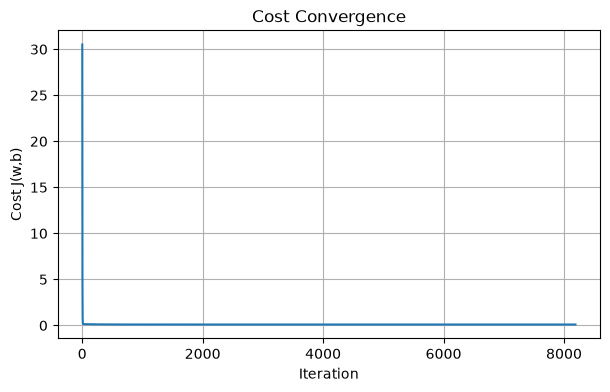

In [8]:
iterations = [row["iteration"] for row in history]
w_history = [row["w"] for row in history]
b_history = [row["b"] for row in history]
cost_history = [row["cost"] for row in history]

plt.figure(figsize=(7, 4))
plt.plot(iterations, cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost Convergence")
plt.grid(True)
plt.show()

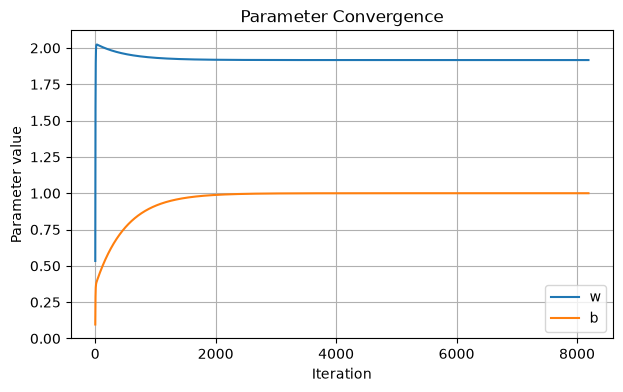

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(iterations, w_history, label="w")
plt.plot(iterations, b_history, label="b")
plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.title("Parameter Convergence")
plt.legend()
plt.grid(True)
plt.show()

## 8. Final Predictions

After convergence, we use the learned parameters:

$$
\hat{y}=wx+b
$$

These are the final predictions of our trained model.


In [10]:
y_pred = compute_prediction(x_train, w, b)

print("Actual values:   ", y_train)
print("Predicted values:", np.round(y_pred, 4))

Actual values:    [ 3.  5.  7.  8. 11. 12. 14. 17.]
Predicted values: [ 2.9167  4.8333  6.75    8.6667 10.5833 12.5    14.4167 16.3333]


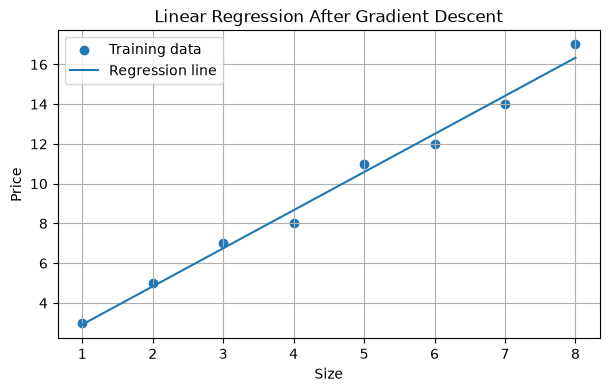

In [11]:
plt.figure(figsize=(7, 4))
plt.scatter(x_train, y_train, label="Training data")
plt.plot(x_train, y_pred, label="Regression line")
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Linear Regression After Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

## 9. Regression Metrics

### Mean Squared Error

$$
MSE=
\frac{1}{m}
\sum_{i=0}^{m-1}
(y^{(i)}-\hat{y}^{(i)})^2
$$

### Root Mean Squared Error

$$
RMSE=\sqrt{MSE}
$$

### Mean Absolute Error

$$
MAE=
\frac{1}{m}
\sum_{i=0}^{m-1}
|y^{(i)}-\hat{y}^{(i)}|
$$

### Coefficient of Determination

$$
R^2=
1-
\frac{\sum(y-\hat{y})^2}
{\sum(y-\bar{y})^2}
$$


In [12]:
errors = y_train - y_pred

mse = np.mean(errors ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(errors))

ss_res = np.sum((y_train - y_pred) ** 2)
ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.6f}")

MSE  : 0.197917
RMSE : 0.444878
MAE  : 0.395833
R²   : 0.989842


## 10. Complete Mathematical Flow

$$
\boxed{f_{w,b}(x)=wx+b}
$$

↓

Calculate the error:

$$
\boxed{error=f_{w,b}(x)-y}
$$

↓

Calculate the cost:

$$
\boxed{
J(w,b)=
\frac{1}{2m}
\sum(error)^2
}
$$

↓

Calculate gradients:

$$
\boxed{
\frac{\partial J}{\partial w}
=
\frac{1}{m}\sum(error)x
}
$$

$$
\boxed{
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum(error)
}
$$

↓

Update parameters:

$$
\boxed{
w_{new}=w-\alpha\frac{\partial J}{\partial w}
}
$$

$$
\boxed{
b_{new}=b-\alpha\frac{\partial J}{\partial b}
}
$$

↓

Check convergence:

$$
\boxed{|w_{new}-w|<\epsilon
\quad\text{and}\quad
|b_{new}-b|<\epsilon}
$$

↓

If not converged → repeat.

If converged → stop.

This means the **number of iterations is determined by convergence**, rather than being treated as the desired number of updates.
